In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# merged_df=pd.read_csv('/kaggle/input/datasets/mdmezbauddin/fake-and-spam-reviews-detection-dataset/merged_fake_spam_reviews_final.csv')
merged_df=pd.read_csv('/home/mezba/Downloads/CSE 330/fake review/data/merged_fake_spam_reviews_augmented_final.csv')
merged_df.head()
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

,category,label,rating,text
0,Home_and_Kitchen,1.0,5.0,"Extremely useful shape and size, and quality i..."
1,Toys_and_Games,0.0,3.0,I feel like a real idiot because all the revie...
2,Home_and_Kitchen,1.0,5.0,UPS delivered this item. The box was a bit wo...
3,Clothing_Shoes_and_Jewelry,1.0,4.0,Looks good. Check out www.fashiondealsweekly.c...
4,Clothing_Shoes_and_Jewelry,1.0,5.0,For the past few fall seasons I have been unab...


In [2]:
print({len(merged_df)})

{45117}


In [3]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
from torch.optim import AdamW
from transformers import RobertaTokenizer, RobertaModel
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from tqdm import tqdm
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack as sparse_hstack
import xgboost as xgb

/home/mezba/Downloads/CSE 330/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
merged_df = merged_df.dropna(subset=['text']).reset_index(drop=True)
dup_texts = merged_df.groupby('text')['label'].nunique()
conflict_texts = dup_texts[dup_texts > 1].index.tolist()
print(f"\nTexts with conflicting labels: {len(conflict_texts)}")

merged_df = merged_df[~merged_df['text'].isin(conflict_texts)].reset_index(drop=True)

before = len(merged_df)
merged_df = merged_df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"Exact duplicates removed: {before - len(merged_df)}")

print(f"\nFinal dataset size: {len(merged_df)}")
print(merged_df['label'].value_counts())
# 0 = Real, 1 = Spam, 2 = Fake


Texts with conflicting labels: 0
Exact duplicates removed: 0

Final dataset size: 45117
label
0.0    22244
1.0    12867
2.0    10006
Name: count, dtype: int64


In [5]:
print(merged_df['label'].value_counts())
print(merged_df['label'].isnull().sum())
train_val_merged, test_dataset_merged = train_test_split(merged_df, test_size=0.1, stratify=merged_df['label'], random_state=42)
train_dataset_merged, validation_dataset_merged = train_test_split(train_val_merged, test_size=0.125, stratify=train_val_merged['label'], random_state=42)


label
0.0    22244
1.0    12867
2.0    10006
Name: count, dtype: int64
0


In [6]:
def compute_rating_sample_weights(df):
    """Compute normalized sample weights from label and rating frequency.

    The final weight blends:
    - label imbalance, so Real does not dominate training overall
    - label/rating imbalance, so common rating buckets do not overwhelm rare ones
      within each class

    The weights are normalized to mean 1.0.
    """
    tmp = df[['label', 'rating']].copy()
    tmp['rating'] = tmp['rating'].fillna(3.0).astype(float)

    total = len(tmp)
    label_counts = tmp['label'].value_counts().to_dict()
    combo_counts = tmp.groupby(['label', 'rating']).size().to_dict()

    num_labels = tmp['label'].nunique()
    num_combos = len(combo_counts)

    weights = []
    for label, rating in tmp.itertuples(index=False, name=None):
        label_weight = total / (num_labels * label_counts[label])
        combo_weight = total / (num_combos * combo_counts[(label, rating)])
        weights.append((label_weight * combo_weight) ** 0.5)

    weights = np.asarray(weights, dtype=np.float32)
    weights /= weights.mean()
    return weights


print("Before weighting:")
print(train_dataset_merged.groupby(['label', 'rating']).size().unstack(fill_value=0))
train_rating_weights = compute_rating_sample_weights(train_dataset_merged)
print("\nCombined weight range:")
print(f"  min={train_rating_weights.min():.4f}")
print(f"  max={train_rating_weights.max():.4f}")
print(f"  mean={train_rating_weights.mean():.4f}")

Before weighting:
rating   1.0   2.0   3.0   4.0   5.0
label                               
0.0     4236  2736  4422  1473  4650
1.0       57    24    21  2290  7741
2.0      452   357   723  1470  4877

Combined weight range:
  min=0.6922
  max=13.5427
  mean=1.0000


In [7]:
print(f"Train size: {len(train_dataset_merged)}")
print(f"Validation size: {len(validation_dataset_merged)}")
print(f"Test size: {len(test_dataset_merged)}")
print(f"Training sample weights computed: {len(train_rating_weights)}")

Train size: 35529
Validation size: 5076
Test size: 4512
Training sample weights computed: 35529


In [8]:
train_texts = train_dataset_merged['text'].values
val_texts = validation_dataset_merged['text'].values
test_texts = test_dataset_merged['text'].values

y_train = train_dataset_merged['label'].values
y_val = validation_dataset_merged['label'].values
y_test = test_dataset_merged['label'].values


In [9]:
def extract_metadata(df):
    meta = pd.DataFrame()
    meta['review_length']       = df['text'].str.len()
    meta['word_count']          = df['text'].str.split().str.len()
    meta['exclamation_count']   = df['text'].str.count('!')
    meta['uppercase_ratio']     = df['text'].apply(
                                    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    meta['has_url']             = df['text'].str.contains(
                                    r'https|http|www|\.com', regex=True).astype(int)
    meta['avg_word_length']     = df['text'].apply(
                                    lambda x: np.mean([len(w) for w in x.split()] + [0]))
    meta['punctuation_density'] = df['text'].apply(
                                    lambda x: sum(1 for c in x if c in '.,!?;:') / (len(x) + 1))
    meta['type_token_ratio']    = df['text'].apply(
                                    lambda x: len(set(x.lower().split())) / (len(x.split()) + 1))
    # meta['rating'] = df['rating'].fillna(3.0).astype(float)
    meta['rating'] = (df['rating'].fillna(3.0) - 3.0) / 2.0
    meta['has_promo'] = df['text'].str.contains(
        r'subscribe|follow us|check out|youtube|instagram|tiktok|'
        r'giveaway|unboxing|our channel|our website|our page',
        case=False, regex=True
    ).astype(int)
    all_categories = ['Electronics', 'Home_and_Kitchen', 'Toys_and_Games', 
                      'Sports_and_Outdoors', 'Clothing_Shoes_and_Jewelry']
    for cat in all_categories:
        meta[f'category_{cat}'] = (df['category'] == cat).astype(float)
        
    return meta.values.astype(np.float32)

In [10]:
META_DIM = 15

print("Extracting metadata features...")
train_meta = extract_metadata(train_dataset_merged)
val_meta   = extract_metadata(validation_dataset_merged)
test_meta  = extract_metadata(test_dataset_merged)
print(f"Metadata shape: {train_meta.shape}")

Extracting metadata features...
Metadata shape: (35529, 15)


In [11]:
class GatedFusionModel(nn.Module):
    def __init__(self, roberta_name='roberta-base', num_labels=3,
                 meta_dim=META_DIM, meta_hidden=32, dropout=0.3,
                 class_weights=None):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(roberta_name)
        hidden = self.roberta.config.hidden_size

        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, meta_hidden),
            nn.GELU(),
        )

        self.gate = nn.Linear(hidden + meta_hidden, hidden)
        self.meta_expand = nn.Linear(meta_hidden, hidden)

        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_labels),
        )

        if class_weights is not None:
            w = torch.tensor(class_weights, dtype=torch.float32)
            self.loss_fn = nn.CrossEntropyLoss(weight=w)
        else:
            self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, input_ids, attention_mask, metadata, labels=None):
        out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = out.last_hidden_state[:, 0, :]
        meta_emb = self.meta_mlp(metadata)
        combined = torch.cat([cls_emb, meta_emb], dim=1)
        g = torch.sigmoid(self.gate(combined))
        meta_exp = self.meta_expand(meta_emb)
        fused = g * cls_emb + (1 - g) * meta_exp
        logits = self.classifier(fused)
        loss = self.loss_fn(logits, labels) if labels is not None else None
        return type('ModelOutput', (), {'loss': loss, 'logits': logits})()

In [12]:
import torch.nn.functional as F

class TextSCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_labels=3,
                 sentence_per_review=8, words_per_sentence=16,
                 filter_widths_sent=(3, 4, 5), num_filters_sent=100,
                 filter_widths_doc=(2, 3), num_filters_doc=100,
                 dropout=0.3, class_weights=None):
        super().__init__()

        self.sentence_per_review = sentence_per_review
        self.words_per_sentence = words_per_sentence
        self.max_len = sentence_per_review * words_per_sentence

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=1)

        self.sent_convs = nn.ModuleList([
            nn.Conv2d(1, num_filters_sent, kernel_size=(fs, embed_dim))
            for fs in filter_widths_sent
        ])
        sent_out_dim = num_filters_sent * len(filter_widths_sent)

        self.doc_convs = nn.ModuleList([
            nn.Conv2d(1, num_filters_doc, kernel_size=(fs, sent_out_dim))
            for fs in filter_widths_doc
        ])
        doc_out_dim = num_filters_doc * len(filter_widths_doc)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(doc_out_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_labels),
        )

        if class_weights is not None:
            w = torch.tensor(class_weights, dtype=torch.float32)
            self.loss_fn = nn.CrossEntropyLoss(weight=w)
        else:
            self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, input_ids, labels=None, **kwargs):
        batch_size = input_ids.size(0)
        seq_len = input_ids.size(1)

        if seq_len < self.max_len:
            pad = torch.ones(batch_size, self.max_len - seq_len,
                             dtype=torch.long, device=input_ids.device)
            input_ids = torch.cat([input_ids, pad], dim=1)
        else:
            input_ids = input_ids[:, :self.max_len]

        x = input_ids.view(batch_size, self.sentence_per_review, self.words_per_sentence)
        x = self.embedding(x)
        x = x.view(batch_size * self.sentence_per_review, self.words_per_sentence, -1)
        x = x.unsqueeze(1)

        sent_features = []
        for conv in self.sent_convs:
            h = F.relu(conv(x))
            h = F.max_pool2d(h, kernel_size=(h.size(2), 1))
            sent_features.append(h)
        sent_features = torch.cat(sent_features, dim=1).squeeze(3).squeeze(2)

        sent_features = sent_features.view(batch_size, self.sentence_per_review, -1)
        sent_features = sent_features.unsqueeze(1)

        doc_features = []
        for conv in self.doc_convs:
            h = F.relu(conv(sent_features))
            h = F.max_pool2d(h, kernel_size=(h.size(2), 1))
            doc_features.append(h)
        doc_features = torch.cat(doc_features, dim=1).squeeze(3).squeeze(2)

        logits = self.classifier(doc_features)
        loss = self.loss_fn(logits, labels) if labels is not None else None
        return type('ModelOutput', (), {'loss': loss, 'logits': logits})()

In [13]:
class ReviewDataset(Dataset):
    def __init__(self, reviews, labels, tokenizer, max_length, metadata=None, sample_weights=None):
        self.reviews = reviews
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.metadata = metadata
        self.sample_weights = sample_weights

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, idx):
        text = str(self.reviews[idx]).strip()
        if not text or text.lower() == 'nan' or len(text) < 2:
            text = "empty review"

        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        if input_ids.size(0) != self.max_length:
            padded = torch.ones(self.max_length, dtype=torch.long)
            mask = torch.zeros(self.max_length, dtype=torch.long)
            length = min(input_ids.size(0), self.max_length)
            padded[:length] = input_ids[:length]
            mask[:length] = attention_mask[:length]
            input_ids, attention_mask = padded, mask

        item = {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': torch.tensor(label, dtype=torch.long),
        }
        if self.metadata is not None:
            item['metadata'] = torch.tensor(self.metadata[idx], dtype=torch.float32)
        if self.sample_weights is not None:
            item['sample_weight'] = torch.tensor(self.sample_weights[idx], dtype=torch.float32)
        return item

In [14]:
def train_model(model, train_loader, val_loader, epochs=3, device='cuda', lr=2e-5):
    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps)
    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct_predictions = 0
        total_samples = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            metadata = batch['metadata'].to(device) if 'metadata' in batch else None
            sample_weight = batch['sample_weight'].to(device) if 'sample_weight' in batch else None

            outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                            metadata=metadata, labels=labels)
            logits = outputs.logits

            per_sample_loss = nn.functional.cross_entropy(logits, labels, reduction='none')
            if sample_weight is not None:
                loss = (per_sample_loss * sample_weight).sum() / sample_weight.sum().clamp_min(1e-8)
            else:
                loss = per_sample_loss.mean()

            total_loss += loss.item()

            loss.backward()
            optimizer.step()
            scheduler.step()

            preds = torch.argmax(logits, dim=1)
            correct_predictions += torch.sum(preds == labels).item()
            total_samples += labels.size(0)

        avg_train_loss = total_loss / len(train_loader)
        train_acc = correct_predictions / total_samples

        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                metadata = batch['metadata'].to(device) if 'metadata' in batch else None

                outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                                metadata=metadata)
                preds = torch.argmax(outputs.logits, dim=1)
                val_correct += torch.sum(preds == labels).item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, ' +
              f'Train Acc={train_acc*100:.2f}%, Val Acc={val_acc*100:.2f}%')

    return model

In [15]:
def evaluate_transformer(model, test_loader, device='cuda'):
    model.eval()
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            metadata = batch['metadata'].to(device) if 'metadata' in batch else None

            outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                            metadata=metadata)
            preds = torch.argmax(outputs.logits, dim=1)
            
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    return np.array(predictions), np.array(true_labels)


In [16]:
def get_probabilities(model, loader, device='cuda'):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Getting probs'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            metadata = batch['metadata'].to(device) if 'metadata' in batch else None
            outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                            metadata=metadata)
            probs = torch.softmax(outputs.logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.extend(batch['labels'].numpy())
    return np.vstack(all_probs), np.array(all_labels)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

print("\n" + "="*80)
print("Training RoBERTa + GatedFusion Model")
print("="*80)

MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 3
results = []

try:
    roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

    roberta_model = GatedFusionModel(
        roberta_name='roberta-base', num_labels=3,
        meta_dim=META_DIM, meta_hidden=32, dropout=0.3)

    train_dataset_roberta = ReviewDataset(
        train_texts, y_train, roberta_tokenizer, MAX_LENGTH,
        metadata=train_meta, sample_weights=train_rating_weights)
    val_dataset_roberta = ReviewDataset(
        val_texts, y_val, roberta_tokenizer, MAX_LENGTH, metadata=val_meta)

    train_loader_roberta = DataLoader(
        train_dataset_roberta, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_roberta = DataLoader(val_dataset_roberta, batch_size=BATCH_SIZE)

    start_time = time.time()
    roberta_model = train_model(
        roberta_model, train_loader_roberta, val_loader_roberta,
        epochs=EPOCHS, device=device)
    roberta_training_time = time.time() - start_time

    roberta_val_preds, roberta_val_labels = evaluate_transformer(
        roberta_model, val_loader_roberta, device=device)
    roberta_val_acc = accuracy_score(roberta_val_labels, roberta_val_preds) * 100

    print(f"\nRoBERTa + GatedFusion — VAL Results:")
    print(f"Training Time : {roberta_training_time:.2f}s")
    print(f"Val Accuracy  : {roberta_val_acc:.2f}%")
    print("\nClassification Report (Val):")
    print(classification_report(
        roberta_val_labels, roberta_val_preds,
        target_names=['Real', 'Spam', 'Fake']))

    results.append({'Model': 'RoBERTa+GatedFusion',
                    'Val_Acc': roberta_val_acc,
                    'Training_Time': roberta_training_time})

except Exception as e:
    print(f"Error training RoBERTa: {e}")
    import traceback
    traceback.print_exc()


Using device: cuda

Training RoBERTa + GatedFusion Model


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1/3: 100%|██████████| 2221/2221 [21:02<00:00,  1.76it/s]


Epoch 1: Train Loss=0.6207, Train Acc=71.43%, Val Acc=76.14%


Epoch 2/3: 100%|██████████| 2221/2221 [19:12<00:00,  1.93it/s]


Epoch 2: Train Loss=0.3882, Train Acc=81.59%, Val Acc=82.35%


Epoch 3/3: 100%|██████████| 2221/2221 [19:18<00:00,  1.92it/s]


Epoch 3: Train Loss=0.3023, Train Acc=85.53%, Val Acc=82.64%


Evaluating: 100%|██████████| 318/318 [00:46<00:00,  6.88it/s]


RoBERTa + GatedFusion — VAL Results:
Training Time : 3717.42s
Val Accuracy  : 82.64%

Classification Report (Val):
              precision    recall  f1-score   support

        Real       0.87      0.78      0.82      2503
        Spam       0.69      0.78      0.74      1447
        Fake       0.92      0.99      0.96      1126

    accuracy                           0.83      5076
   macro avg       0.83      0.85      0.84      5076
weighted avg       0.83      0.83      0.83      5076



In [17]:
print("\n" + "="*80)
print("Training TextSCNN Model")
print("="*80)

try:
    VOCAB_SIZE = roberta_tokenizer.vocab_size
    scnn_model = TextSCNN(
        vocab_size=VOCAB_SIZE, embed_dim=128, num_labels=3,
        sentence_per_review=8,
        words_per_sentence=16,
        filter_widths_sent=(3, 4, 5), num_filters_sent=100,
        filter_widths_doc=(2, 3), num_filters_doc=100,
        dropout=0.3,
    )

    start_time = time.time()
    scnn_model = train_model(
        scnn_model, train_loader_roberta, val_loader_roberta,
        epochs=5, device=device, lr=1e-3)
    scnn_training_time = time.time() - start_time

    scnn_val_preds, scnn_val_labels = evaluate_transformer(
        scnn_model, val_loader_roberta, device=device)
    scnn_val_acc = accuracy_score(scnn_val_labels, scnn_val_preds) * 100

    print(f"\nTextSCNN — VAL Results:")
    print(f"Training Time : {scnn_training_time:.2f}s")
    print(f"Val Accuracy  : {scnn_val_acc:.2f}%")
    print(classification_report(
        scnn_val_labels, scnn_val_preds,
        target_names=['Real', 'Spam', 'Fake']))

    results.append({'Model': 'TextSCNN',
                    'Val_Acc': scnn_val_acc,
                    'Training_Time': scnn_training_time})

except Exception as e:
    print(f"Error training TextSCNN: {e}")
    import traceback
    traceback.print_exc()


Training TextSCNN Model


Epoch 1/5: 100%|██████████| 2221/2221 [00:43<00:00, 51.52it/s]


Epoch 1: Train Loss=0.6579, Train Acc=64.34%, Val Acc=68.30%


Epoch 2/5: 100%|██████████| 2221/2221 [00:39<00:00, 56.30it/s]


Epoch 2: Train Loss=0.5197, Train Acc=68.60%, Val Acc=68.87%


...

Epoch 4: Train Loss=0.4201, Train Acc=73.70%, Val Acc=70.88%


Epoch 5/5: 100%|██████████| 2221/2221 [00:37<00:00, 58.60it/s]


Epoch 5: Train Loss=0.3661, Train Acc=78.28%, Val Acc=70.23%


Evaluating: 100%|██████████| 318/318 [00:03<00:00, 93.48it/s]


TextSCNN — VAL Results:
Training Time : 210.82s
Val Accuracy  : 70.23%
              precision    recall  f1-score   support

        Real       0.73      0.66      0.69      2503
        Spam       0.51      0.60      0.55      1447
        Fake       0.94      0.93      0.93      1126

    accuracy                           0.70      5076
   macro avg       0.73      0.73      0.73      5076
weighted avg       0.71      0.70      0.71      5076



In [18]:
# Results are appended in the TextSCNN training cell above.

In [19]:
print("\n" + "="*80)
print("Training XGBoost Model  (TF-IDF + Metadata)")
print("="*80)

try:
    print("Vectorizing text with TF-IDF...")
    tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
    X_train_tfidf = tfidf.fit_transform(train_texts)
    X_val_tfidf = tfidf.transform(val_texts)

    X_train_xgb = sparse_hstack([X_train_tfidf, train_meta])
    X_val_xgb = sparse_hstack([X_val_tfidf, val_meta])
    print(f"XGBoost feature matrix shape: {X_train_xgb.shape}")

    start_time = time.time()
    xgb_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=3,
        eval_metric='mlogloss', n_jobs=-1, random_state=42,
    )

    xgb_model.fit(
        X_train_xgb, y_train.astype(int),
        sample_weight=train_rating_weights,
        eval_set=[(X_val_xgb, y_val.astype(int))],
        verbose=50,
    )
    xgb_training_time = time.time() - start_time

    xgb_val_preds = xgb_model.predict(X_val_xgb)
    xgb_val_acc = accuracy_score(y_val.astype(int), xgb_val_preds) * 100

    print(f"\nXGBoost — VAL Results:")
    print(f"Training Time : {xgb_training_time:.2f}s")
    print(f"Val Accuracy  : {xgb_val_acc:.2f}%")
    print("\nClassification Report (Val):")
    print(classification_report(
        y_val.astype(int), xgb_val_preds,
        target_names=['Real', 'Spam', 'Fake']))

    results.append({'Model': 'XGBoost (TF-IDF+Meta)',
                    'Val_Acc': xgb_val_acc,
                    'Training_Time': xgb_training_time})

    print(f"\n{'='*60}")
    print("INDIVIDUAL MODELS — VAL COMPARISON")
    print(f"{'='*60}")
    print(pd.DataFrame(results).to_string(index=False))

except Exception as e:
    print(f"Error training XGBoost: {e}")
    import traceback
    traceback.print_exc()


Training XGBoost Model  (TF-IDF + Metadata)
Vectorizing text with TF-IDF...
XGBoost feature matrix shape: (35529, 10015)
[0]	validation_0-mlogloss:1.02530
[50]	validation_0-mlogloss:0.52833
[100]	validation_0-mlogloss:0.47059
[150]	validation_0-mlogloss:0.44288
[200]	validation_0-mlogloss:0.42491
[250]	validation_0-mlogloss:0.41305
[299]	validation_0-mlogloss:0.40419

XGBoost — VAL Results:
Training Time : 442.32s
Val Accuracy  : 82.29%

Classification Report (Val):
              precision    recall  f1-score   support

        Real       0.91      0.75      0.82      2503
        Spam       0.69      0.90      0.78      1447
        Fake       0.89      0.89      0.89      1126

    accuracy                           0.82      5076
   macro avg       0.83      0.85      0.83      5076
weighted avg       0.84      0.82      0.82      5076


INDIVIDUAL MODELS — VAL COMPARISON
                Model   Val_Acc  Training_Time
  RoBERTa+GatedFusion 82.643814    3717.422430
             Text

In [20]:
print("\n" + "="*80)
print("="*80)

try:
    from sklearn.metrics import f1_score

    print("\nStep 1: Collecting VAL probabilities for meta-learner training...")
    roberta_val_probs, val_labels_arr = get_probabilities(
        roberta_model, val_loader_roberta, device)
    cnn_val_probs,    _               = get_probabilities(
        scnn_model,     val_loader_roberta, device)
    
    xgb_val_probs = xgb_model.predict_proba(X_val_xgb)

    stack_val    = np.hstack([roberta_val_probs, cnn_val_probs,
                                xgb_val_probs])
    meta_learner = LogisticRegression(
        max_iter=1000, C=1.0, random_state=42)
    meta_learner.fit(stack_val, val_labels_arr.astype(int))
    print(f"  Meta-learner trained on val stack shape: {stack_val.shape}")
    prob=meta_learner.predict_proba(stack_val)
    print(f"  Meta-learner val accuracy: {accuracy_score(val_labels_arr.astype(int), meta_learner.predict(stack_val)) * 100:.2f}%")
except Exception as e:
    print(f"Error in final evaluation: {e}")
    import traceback
    traceback.print_exc()



Step 1: Collecting VAL probabilities for meta-learner training...


Getting probs: 100%|██████████| 318/318 [00:02<00:00, 108.18it/s]


  Meta-learner trained on val stack shape: (5076, 9)
  Meta-learner val accuracy: 87.16%


In [21]:
test_dataset_roberta = ReviewDataset(
    test_texts, y_test, roberta_tokenizer, MAX_LENGTH, metadata=test_meta)
test_loader_roberta = DataLoader(test_dataset_roberta, batch_size=BATCH_SIZE)
test_loader_scnn = test_loader_roberta
X_test_tfidf = tfidf.transform(test_texts)
X_test_xgb   = sparse_hstack([X_test_tfidf, test_meta])

In [22]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, classification_report,
                              confusion_matrix)

In [23]:
CLASS_NAMES = ['Real', 'Spam', 'Fake']


In [24]:
print("\nStep 2: Collecting TEST probabilities (first and only time)...")
roberta_test_probs, test_labels_arr = get_probabilities(roberta_model, test_loader_roberta, device)
scnn_test_probs,    _               = get_probabilities(scnn_model,    test_loader_scnn,    device)
xgb_test_probs                      = xgb_model.predict_proba(X_test_xgb)
test_labels_arr                     = test_labels_arr.astype(int)



Step 2: Collecting TEST probabilities (first and only time)...


Getting probs: 100%|██████████| 282/282 [00:02<00:00, 105.34it/s]


In [25]:
def get_preds_conf(probs):
    """Return (hard predictions, confidence = max probability)."""
    preds = np.argmax(probs, axis=1)
    conf  = np.max(probs, axis=1)
    return preds, conf


In [26]:
roberta_preds, roberta_conf = get_preds_conf(roberta_test_probs)
scnn_preds,    scnn_conf    = get_preds_conf(scnn_test_probs)
xgb_preds,     xgb_conf    = get_preds_conf(xgb_test_probs)


In [27]:
# Stacking
stack_test     = np.hstack([roberta_test_probs, scnn_test_probs, xgb_test_probs])
stack_probs    = meta_learner.predict_proba(stack_test)
stack_preds, stack_conf = get_preds_conf(stack_probs)


In [28]:
def full_metrics(name, preds, probs, true_labels):
    acc    = accuracy_score(true_labels, preds) * 100
    mac_f1 = f1_score(true_labels, preds, average='macro')  * 100
    mac_pr = precision_score(true_labels, preds, average='macro', zero_division=0) * 100
    mac_re = recall_score(true_labels, preds, average='macro', zero_division=0) * 100
    try:
        auc = roc_auc_score(true_labels, probs, multi_class='ovr', average='macro') * 100
    except Exception:
        auc = float('nan')
    per_f1 = f1_score(true_labels, preds, average=None, zero_division=0) * 100
    conf_correct   = np.mean(np.max(probs, axis=1)[preds == true_labels])
    conf_incorrect = np.mean(np.max(probs, axis=1)[preds != true_labels]) if (preds != true_labels).any() else float('nan')
    return {'Model': name, 'Acc': acc, 'MacF1': mac_f1, 'MacPrec': mac_pr,
            'MacRec': mac_re, 'AUC': auc, 'RealF1': per_f1[0],
            'SpamF1': per_f1[1], 'FakeF1': per_f1[2],
            'Conf_Correct': conf_correct*100, 'Conf_Wrong': conf_incorrect*100}


In [29]:
rows = [
    full_metrics('RoBERTa+GatedFusion', roberta_preds, roberta_test_probs, test_labels_arr),
    full_metrics('TextSCNN',            scnn_preds,    scnn_test_probs,    test_labels_arr),
    full_metrics('XGBoost',             xgb_preds,     xgb_test_probs,     test_labels_arr),
    full_metrics('Stacking Ensemble',   stack_preds,   stack_probs,        test_labels_arr),
]
df_results = pd.DataFrame(rows)


Model                       Acc   MacF1   Prec    Rec    AUC   Real   Spam   Fake   Conf✓   Conf✗
----------------------------------------------------------------------------------------------------
RoBERTa+GatedFusion       82.5%   83.7%  82.9%  85.2%  94.6%  81.8%  74.1%  95.3%   88.2%   69.4%
TextSCNN                  70.9%   73.2%  73.1%  73.6%  86.4%  69.8%  55.9%  93.9%   78.0%   64.5%
XGBoost                   82.5%   83.1%  82.8%  84.8%  95.2%  82.7%  77.8%  88.9%   83.0%   60.5%
Stacking Ensemble         87.6%   88.4%  88.0%  89.1%  96.9%  87.3%  80.7%  97.3%   90.4%   69.1%


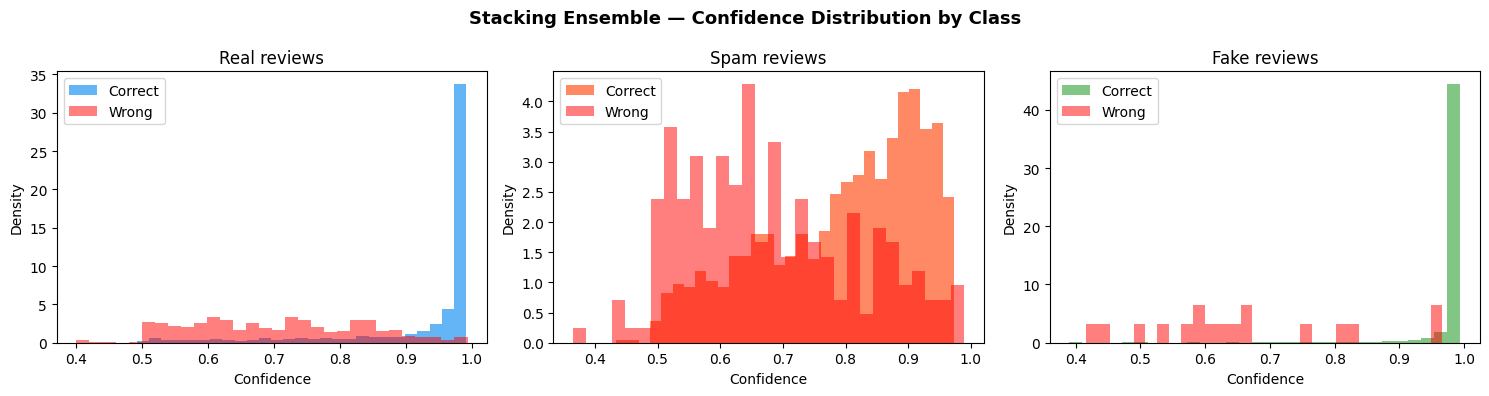

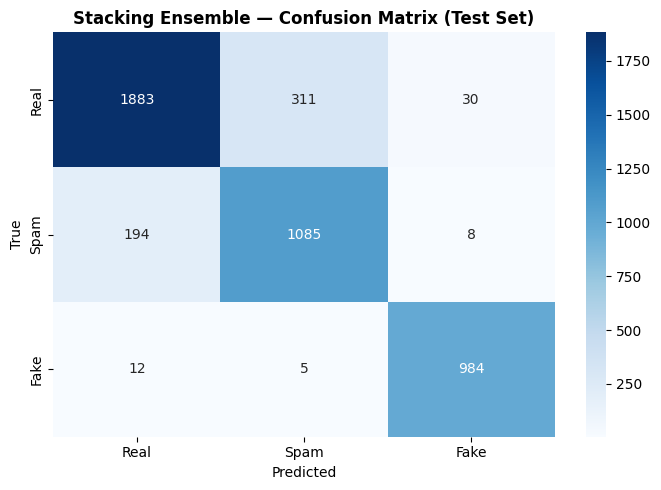

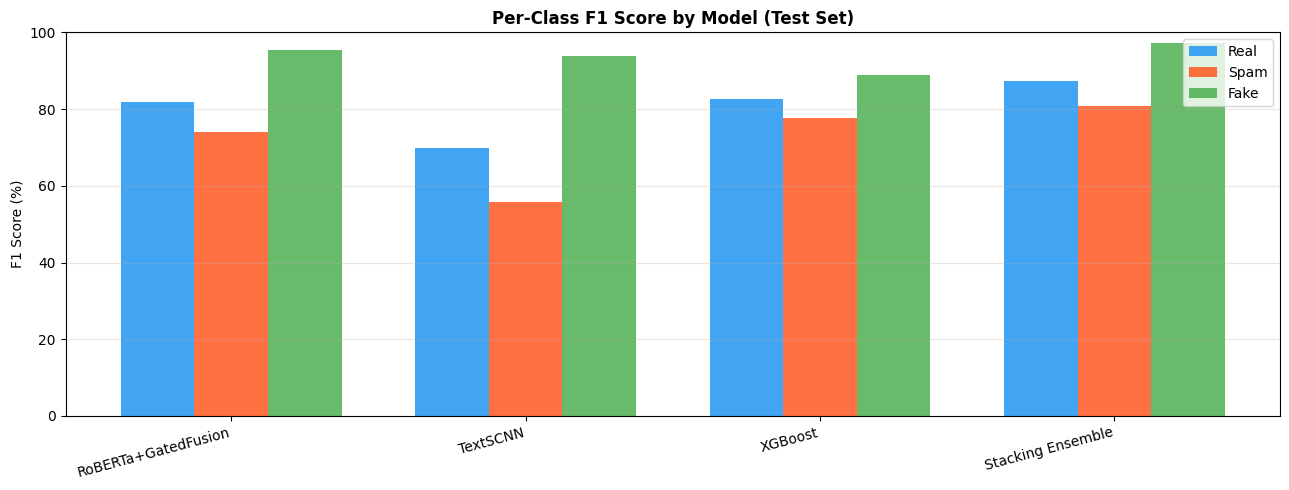


✓ Phase 2 complete. All plots saved.

Full classification report — Stacking Ensemble:
              precision    recall  f1-score   support

        Real       0.90      0.85      0.87      2224
        Spam       0.77      0.84      0.81      1287
        Fake       0.96      0.98      0.97      1001

    accuracy                           0.88      4512
   macro avg       0.88      0.89      0.88      4512
weighted avg       0.88      0.88      0.88      4512



In [30]:
print("\n" + "="*100)
cols = ['Model','Acc','MacF1','MacPrec','MacRec','AUC','RealF1','SpamF1','FakeF1','Conf_Correct','Conf_Wrong']
hdr = f"{'Model':<24} {'Acc':>6} {'MacF1':>7} {'Prec':>6} {'Rec':>6} {'AUC':>6} {'Real':>6} {'Spam':>6} {'Fake':>6} {'Conf✓':>7} {'Conf✗':>7}"
print(hdr)
print("-"*100)
for _, r in df_results.iterrows():
    print(f"{r['Model']:<24} {r['Acc']:>5.1f}% {r['MacF1']:>6.1f}% {r['MacPrec']:>5.1f}% "
          f"{r['MacRec']:>5.1f}% {r['AUC']:>5.1f}% {r['RealF1']:>5.1f}% "
          f"{r['SpamF1']:>5.1f}% {r['FakeF1']:>5.1f}% "
          f"{r['Conf_Correct']:>6.1f}% {r['Conf_Wrong']:>6.1f}%")
print("="*100)

#  Confidence distribution plot ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Stacking Ensemble — Confidence Distribution by Class', fontsize=13, fontweight='bold')
colors = ['#2196F3', '#FF5722', '#4CAF50']
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
    mask = test_labels_arr == i
    axes[i].hist(stack_conf[mask & (stack_preds == test_labels_arr)],
                 bins=30, alpha=0.7, color=col,  label='Correct', density=True)
    wrong_mask = mask & (stack_preds != test_labels_arr)
    if wrong_mask.any():
        axes[i].hist(stack_conf[wrong_mask],
                     bins=30, alpha=0.5, color='red', label='Wrong',   density=True)
    axes[i].set_title(f'{cls} reviews')
    axes[i].set_xlabel('Confidence')
    axes[i].set_ylabel('Density')
    axes[i].legend()
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#  Confusion matrix — stacking ───────────────────────────
cm = confusion_matrix(test_labels_arr, stack_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Stacking Ensemble — Confusion Matrix (Test Set)', fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('stacking_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class F1 bar chart ────────────────────────────────
model_names = [r['Model'] for _, r in df_results.iterrows()]
real_f1  = df_results['RealF1'].values
spam_f1  = df_results['SpamF1'].values
fake_f1  = df_results['FakeF1'].values

x = np.arange(len(model_names))
w = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w, real_f1, w, label='Real',  color='#2196F3', alpha=0.85)
ax.bar(x,     spam_f1, w, label='Spam',  color='#FF5722', alpha=0.85)
ax.bar(x + w, fake_f1, w, label='Fake',  color='#4CAF50', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('F1 Score (%)'); ax.set_ylim(0, 100)
ax.set_title('Per-Class F1 Score by Model (Test Set)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Phase 2 complete. All plots saved.")
print("\nFull classification report — Stacking Ensemble:")
print(classification_report(test_labels_arr, stack_preds, target_names=CLASS_NAMES))


In [31]:
import sys, os
sys.path.insert(0, '/home/mezba/Downloads/CSE 330/fake review')
from save_models import save_artifacts

save_artifacts(
    roberta_model=roberta_model,
    scnn_model=scnn_model,
    xgb_model=xgb_model,
    tfidf=tfidf,
    meta_learner=meta_learner,
    roberta_tokenizer=roberta_tokenizer,
)


Saved gated_fusion.pt
Saved textscnn.pt
Saved xgboost.pkl
Saved tfidf_vectorizer.pkl
Saved meta_learner.pkl
Saved tokenizer/

All artifacts saved to /home/mezba/Downloads/CSE 330/fake review/saved_models
